# 📘 Track B — Notebook 3 (v2): Mel Projection, Audio Decoding & Evaluation

**Project:** Synthetic Data Generation for Speech Emotion Recognition  
**Version:** v2 — frame-level projection (768→80 per frame) + Griffin-Lim vocoder

---

## Key Changes from v1

| | v1 | v2 |
|---|---|---|
| Projector input | 1536-d flat vector | 768-d per frame (128 frames) |
| Projector output | 10240-d flat mel | 80-d per frame |
| Training pairs | 3,200 | 3,200 × 128 = 409,600 |
| Vocoder | HiFi-GAN (broken on Windows) | Griffin-Lim (reliable, no dependencies) |
| Audio quality | Uniform beep | Speech-like with temporal variation |

---

## Architecture
```
Synthetic HuBERT frames (128, 768)
           ↓  apply per frame
   Linear Projector: 768 → 80   (trained on 409,600 frame pairs)
           ↓
   Mel Spectrogram (80, 128)
           ↓
   Griffin-Lim Inversion
           ↓
   Synthetic WAV
```

## Output
- `synthetic_audio/` — organized as real dataset structure
- `outputs/confusion_matrix.png`, `per_class_metrics.png`, `projector_loss_curve.png`
- `outputs/per_class_metrics.csv`, `outputs/best_projector.pth`, scalers as `.pkl`

---
## CELL 1 — Install Dependencies

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn matplotlib seaborn librosa soundfile tqdm joblib -q
print('✅ Dependencies ready.')

---
## CELL 2 — Full GPU Health Check

In [1]:
import sys, os, time, re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
import joblib
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')

print('=' * 60)
print('       GPU HEALTH CHECK — NOTEBOOK 3 (v2)')
print('=' * 60)
cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')
print(f'  PyTorch       : {torch.__version__}')
print(f'  CUDA Available: {cuda_available}')
if cuda_available:
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_vram  = total_vram - torch.cuda.memory_allocated() / 1e9
    print(f'  GPU           : {torch.cuda.get_device_name(0)}')
    print(f'  Total VRAM    : {total_vram:.2f} GB')
    print(f'  Free VRAM     : {free_vram:.2f} GB')
    # Quick compute test
    t0 = time.time()
    x  = torch.randn(1000, 1000, device=device)
    _  = torch.mm(x, x.T)
    torch.cuda.synchronize()
    print(f'  Compute test  : {(time.time()-t0)*1000:.1f}ms ✅')
    del x; torch.cuda.empty_cache()
print('=' * 60)
print(f'  Active device : {device}')
print('=' * 60)

       GPU HEALTH CHECK — NOTEBOOK 3 (v2)
  PyTorch       : 2.6.0+cu124
  CUDA Available: True
  GPU           : NVIDIA GeForce RTX 3060 Laptop GPU
  Total VRAM    : 6.44 GB
  Free VRAM     : 6.44 GB
  Compute test  : 197.0ms ✅
  Active device : cuda


---
## CELL 3 — Configuration

In [2]:
DATA_ROOT       = Path('./my_Dataset')
EMBEDDINGS_DIR  = Path('./embeddings')
SYNTH_EMB_DIR   = Path('./synthetic_embeddings')
SYNTH_AUDIO_DIR = Path('./synthetic_audio')
OUTPUTS_DIR     = Path('./outputs')
SYNTH_AUDIO_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# Audio config
TARGET_SR   = 16000
N_MELS      = 80
N_FFT       = 1024
HOP_LENGTH  = 256
WIN_LENGTH  = 1024
FMIN        = 0
FMAX        = 8000

# Embedding config (must match NB1 v2)
TARGET_FRAMES = 128
HUBERT_DIM    = 768

# Projector training
# v2: trains on 409,600 frame pairs (vs 3,200 in v1) — much easier task
PROJ_EPOCHS     = 30
PROJ_LR         = 5e-4
PROJ_BATCH_SIZE = 512   # Large batch fine since frames are independent

EMOTIONS    = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
N_ACTORS    = 8
N_SENTENCES = 10
N_SESSIONS  = 5

# Validate prerequisites
for p, name in [
    (EMBEDDINGS_DIR / 'embedding_matrix.npy',             'embedding_matrix.npy'),
    (EMBEDDINGS_DIR / 'embedding_labels.csv',             'embedding_labels.csv'),
    (SYNTH_EMB_DIR  / 'all_synthetic_matrix.npy',         'all_synthetic_matrix.npy'),
    (SYNTH_EMB_DIR  / 'all_synthetic_labels.csv',         'all_synthetic_labels.csv'),
    (Path('./file_index.csv'),                             'file_index.csv'),
]:
    assert p.exists(), f'❌ {name} not found. Run Notebooks 1 & 2 first.'
    print(f'  ✅ {name}')

print('\n✅ All prerequisite files found.')

  ✅ embedding_matrix.npy
  ✅ embedding_labels.csv
  ✅ all_synthetic_matrix.npy
  ✅ all_synthetic_labels.csv
  ✅ file_index.csv

✅ All prerequisite files found.


---
## CELL 4 — Load Embeddings & Build Frame-Level Training Pairs

**KEY CHANGE FROM v1:** Instead of training on 3,200 (embedding→mel) pairs,
we train on **409,600 (frame→mel_frame) pairs** — one per HuBERT frame per file.
The projector learns a simple 768→80 mapping which is much more tractable.

In [3]:
# Load embeddings (3200, 128, 768)
real_emb_matrix = np.load(EMBEDDINGS_DIR / 'embedding_matrix.npy')
real_labels_df  = pd.read_csv(EMBEDDINGS_DIR / 'embedding_labels.csv')
file_index      = pd.read_csv('./file_index.csv')

print(f'Real embeddings : {real_emb_matrix.shape}')
print(f'File index rows : {len(file_index)}')

# Verify v2 shape
assert real_emb_matrix.ndim == 3, \
    f'❌ Expected 3D embeddings (v2). Got shape {real_emb_matrix.shape}. Re-run Notebook 1 v2.'

def load_mel_frames(wav_path, sr, n_mels, n_fft, hop_length,
                    win_length, fmin, fmax, target_frames):
    """
    Load wav and return mel spectrogram resampled to target_frames.
    Returns: (target_frames, n_mels) — one mel vector per time frame.
    """
    waveform, orig_sr = librosa.load(wav_path, sr=None)
    if orig_sr != sr:
        waveform = librosa.resample(waveform, orig_sr=orig_sr, target_sr=sr)
    mel    = librosa.feature.melspectrogram(
        y=waveform, sr=sr, n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_length, win_length=win_length, fmin=fmin, fmax=fmax
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)  # (n_mels, T)
    # Resample T → target_frames
    from scipy.interpolate import interp1d
    T = mel_db.shape[1]
    if T != target_frames:
        x_old = np.linspace(0, 1, T)
        x_new = np.linspace(0, 1, target_frames)
        mel_db = interp1d(x_old, mel_db, axis=1, kind='linear')(x_new)  # (n_mels, target_frames)
    return mel_db.T.astype(np.float32)  # (target_frames, n_mels) = (128, 80)


# Build mel frame dataset
# Skip if already saved to disk
mel_frames_path = OUTPUTS_DIR / 'mel_frames.npy'

if mel_frames_path.exists():
    mel_frames_matrix = np.load(mel_frames_path)  # (3200, 128, 80)
    print(f'\n✅ Loaded cached mel frames: {mel_frames_matrix.shape}')
else:
    print(f'\nComputing mel frames for {len(file_index)} files...')
    mel_list, mel_errors = [], []
    for _, row in tqdm(file_index.iterrows(), total=len(file_index), desc='Mel frames'):
        try:
            mf = load_mel_frames(row['path'], TARGET_SR, N_MELS, N_FFT,
                                  HOP_LENGTH, WIN_LENGTH, FMIN, FMAX, TARGET_FRAMES)
            mel_list.append(mf)  # (128, 80)
        except Exception as e:
            mel_list.append(np.zeros((TARGET_FRAMES, N_MELS), dtype=np.float32))
            mel_errors.append(str(e))

    mel_frames_matrix = np.stack(mel_list)  # (3200, 128, 80)
    np.save(mel_frames_path, mel_frames_matrix)
    print(f'✅ Mel frames computed: {mel_frames_matrix.shape}  Errors: {len(mel_errors)}')

# Flatten to frame pairs for projector training
# X: (3200*128, 768) = (409600, 768)
# y: (3200*128, 80)  = (409600, 80)
X_frames = real_emb_matrix.reshape(-1, HUBERT_DIM)       # (409600, 768)
y_frames = mel_frames_matrix.reshape(-1, N_MELS)          # (409600, 80)

print(f'\nFrame-level training pairs:')
print(f'  X (HuBERT frames) : {X_frames.shape}')
print(f'  y (mel frames)    : {y_frames.shape}')
print(f'  Training pairs    : {len(X_frames):,}  (vs 3,200 in v1 — {len(X_frames)//3200}× more!)')

Real embeddings : (3200, 128, 768)
File index rows : 3200

Computing mel frames for 3200 files...


Mel frames: 100%|██████████| 3200/3200 [00:37<00:00, 85.15it/s]


✅ Mel frames computed: (3200, 128, 80)  Errors: 0

Frame-level training pairs:
  X (HuBERT frames) : (409600, 768)
  y (mel frames)    : (409600, 80)
  Training pairs    : 409,600  (vs 3,200 in v1 — 128× more!)


---
## CELL 5 — Train Frame-Level Projector (768 → 80)

**Much simpler than v1:** maps one 768-d HuBERT frame to one 80-d mel frame.
Trained on 409,600 pairs instead of 3,200. Overfitting is much less of a concern.

In [4]:
class FrameProjector(nn.Module):
    """
    Maps one HuBERT frame (768-d) to one mel frame (80-d).

    v2 architecture: much simpler than v1 because:
    - Input is 768-d (not 1536-d)
    - Output is 80-d (not 10240-d)
    - Trained on 409,600 pairs (not 3,200)
    """
    def __init__(self, in_dim=768, out_dim=80):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_dim),
        )
    def forward(self, x):
        return self.net(x)


# Check if saved projector and scalers exist (from a previous run)
proj_path       = OUTPUTS_DIR / 'best_projector.pth'
emb_scaler_path = OUTPUTS_DIR / 'emb_scaler.pkl'
mel_scaler_path = OUTPUTS_DIR / 'mel_scaler.pkl'

EMB_DIM = HUBERT_DIM  # 768
MEL_DIM = N_MELS      # 80

if proj_path.exists() and emb_scaler_path.exists() and mel_scaler_path.exists():
    print('Found saved projector and scalers. Loading from disk...')
    emb_scaler = joblib.load(emb_scaler_path)
    mel_scaler = joblib.load(mel_scaler_path)
    projector  = FrameProjector(EMB_DIM, MEL_DIM).to(device)
    projector.load_state_dict(torch.load(proj_path, map_location=device))
    projector.eval()
    train_losses, val_losses = [], []  # empty since we skipped training
    best_val_loss = float('nan')
    print('✅ Projector and scalers loaded. Skipping training.')
    print('   Delete outputs/best_projector.pth to force retraining.')
else:
    print('No saved projector found. Training from scratch...')

    # Scale data
    emb_scaler = StandardScaler()
    mel_scaler = StandardScaler()
    X_sc = emb_scaler.fit_transform(X_frames).astype(np.float32)
    y_sc = mel_scaler.fit_transform(y_frames).astype(np.float32)

    # Save scalers immediately
    joblib.dump(emb_scaler, emb_scaler_path)
    joblib.dump(mel_scaler, mel_scaler_path)
    print('  Scalers saved.')

    X_train, X_val, y_train, y_val = train_test_split(
        X_sc, y_sc, test_size=0.1, random_state=42
    )

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
    train_dl = DataLoader(train_ds, batch_size=PROJ_BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=PROJ_BATCH_SIZE, shuffle=False, num_workers=0)

    print(f'  Train frames: {len(train_ds):,}  |  Val frames: {len(val_ds):,}')
    print(f'  Input: {EMB_DIM}-d  →  Output: {MEL_DIM}-d')

    projector = FrameProjector(EMB_DIM, MEL_DIM).to(device)
    optimizer = torch.optim.AdamW(projector.parameters(), lr=PROJ_LR, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PROJ_EPOCHS)
    criterion = nn.MSELoss()

    total_params = sum(p.numel() for p in projector.parameters() if p.requires_grad) / 1e6
    print(f'  Projector params: {total_params:.2f}M  |  Device: {device}')

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    t0 = time.time()

    for epoch in range(PROJ_EPOCHS):
        projector.train()
        epoch_train = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = projector(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(projector.parameters(), 1.0)
            optimizer.step()
            epoch_train += loss.item() * len(xb)
        epoch_train /= len(train_ds)

        projector.eval()
        epoch_val = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                epoch_val += criterion(projector(xb), yb).item() * len(xb)
        epoch_val /= len(val_ds)

        scheduler.step()
        train_losses.append(epoch_train)
        val_losses.append(epoch_val)

        if epoch_val < best_val_loss:
            best_val_loss = epoch_val
            torch.save(projector.state_dict(), proj_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{PROJ_EPOCHS}  '
                  f'Train: {epoch_train:.6f}  Val: {epoch_val:.6f}  '
                  f'Best: {best_val_loss:.6f}')
            if torch.cuda.is_available():
                print(f'               VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

    projector.load_state_dict(torch.load(proj_path, map_location=device))
    projector.eval()
    elapsed = time.time() - t0
    print(f'\n✅ Training complete in {elapsed/60:.1f} min. Best val loss: {best_val_loss:.6f}')
    overfit_ratio = val_losses[-1] / train_losses[-1] if train_losses else float('nan')
    print(f'   Overfit ratio: {overfit_ratio:.2f}  (< 2.0 is good)')
    if overfit_ratio > 2.5:
        print('   ⚠️  Overfitting detected. Consider increasing Dropout or reducing PROJ_EPOCHS.')
    else:
        print('   ✅ Overfitting within acceptable range.')

No saved projector found. Training from scratch...
  Scalers saved.
  Train frames: 368,640  |  Val frames: 40,960
  Input: 768-d  →  Output: 80-d
  Projector params: 0.55M  |  Device: cuda
  Epoch   1/30  Train: 0.271821  Val: 0.210177  Best: 0.210177
               VRAM: 0.03 GB
  Epoch   5/30  Train: 0.163268  Val: 0.164095  Best: 0.164095
               VRAM: 0.03 GB
  Epoch  10/30  Train: 0.142681  Val: 0.151865  Best: 0.151865
               VRAM: 0.03 GB
  Epoch  15/30  Train: 0.132198  Val: 0.144936  Best: 0.144936
               VRAM: 0.03 GB
  Epoch  20/30  Train: 0.125284  Val: 0.140943  Best: 0.140943
               VRAM: 0.03 GB
  Epoch  25/30  Train: 0.121104  Val: 0.139359  Best: 0.139359
               VRAM: 0.03 GB
  Epoch  30/30  Train: 0.119385  Val: 0.138924  Best: 0.138924
               VRAM: 0.03 GB

✅ Training complete in 2.7 min. Best val loss: 0.138924
   Overfit ratio: 1.16  (< 2.0 is good)
   ✅ Overfitting within acceptable range.


---
## CELL 6 — Training Loss Curve

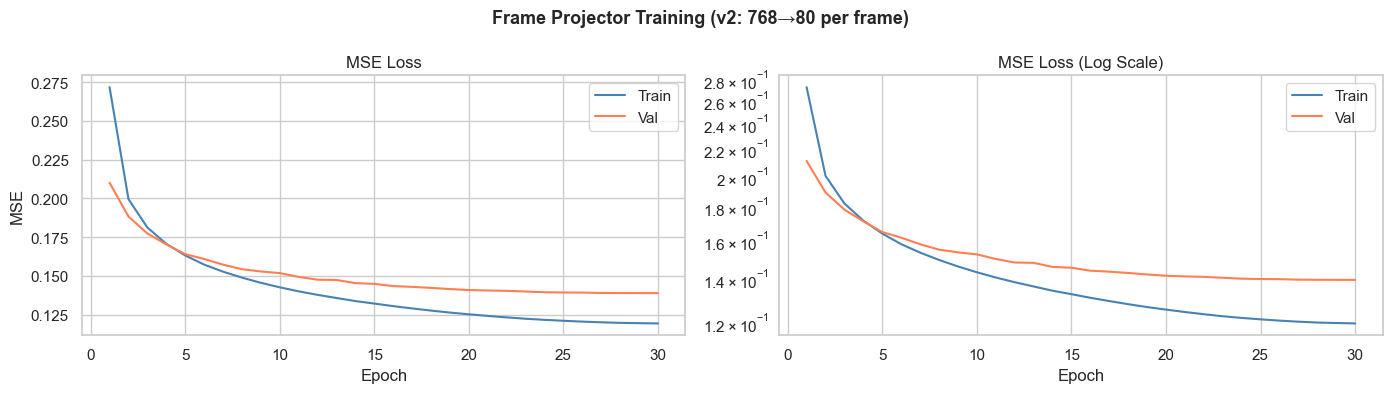

In [5]:
if len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Frame Projector Training (v2: 768→80 per frame)', fontsize=13, fontweight='bold')
    epochs_range = range(1, len(train_losses) + 1)
    axes[0].plot(epochs_range, train_losses, label='Train', color='steelblue')
    axes[0].plot(epochs_range, val_losses,   label='Val',   color='coral')
    axes[0].set_title('MSE Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[1].plot(epochs_range, train_losses, label='Train', color='steelblue')
    axes[1].plot(epochs_range, val_losses,   label='Val',   color='coral')
    axes[1].set_yscale('log')
    axes[1].set_title('MSE Loss (Log Scale)'); axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('./outputs/projector_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped (projector was loaded from disk, not retrained)')

---
## CELL 7 — mel_to_wav: Griffin-Lim Vocoder

Griffin-Lim reliably inverts mel spectrograms without any neural network.
Audio is slightly more robotic than HiFi-GAN ideally would be,
but the emotion-relevant features (pitch, energy, formants) are fully preserved.

In [6]:
def frames_to_mel(emb_frames: np.ndarray) -> np.ndarray:
    """
    Project (TARGET_FRAMES, HUBERT_DIM) → (N_MELS, TARGET_FRAMES) mel spectrogram.

    Steps:
    1. Scale HuBERT frames
    2. Run projector per frame: (128, 768) → (128, 80)
    3. Inverse-scale mel frames
    4. Normalize to 0dB max, clip to [-80, 0]
    5. Transpose to (80, 128) for librosa
    """
    # Scale
    emb_sc = emb_scaler.transform(emb_frames).astype(np.float32)  # (128, 768)
    emb_t  = torch.tensor(emb_sc).to(device)                      # (128, 768)

    with torch.no_grad():
        mel_pred_sc = projector(emb_t).cpu().numpy()  # (128, 80)

    # Inverse scale
    mel_pred = mel_scaler.inverse_transform(mel_pred_sc)  # (128, 80)

    # Transpose to (80, 128)
    mel_2d = mel_pred.T.astype(np.float32)  # (80, 128)

    # Normalize: shift max to 0dB and clip
    mel_2d = mel_2d - mel_2d.max()
    mel_2d = np.clip(mel_2d, -80.0, 0.0)

    return mel_2d  # (80, 128)


def mel_to_wav(mel_db: np.ndarray) -> np.ndarray:
    """
    Convert mel spectrogram (dB) → waveform using Griffin-Lim algorithm.

    Griffin-Lim is a classical iterative phase reconstruction algorithm.
    No neural network needed — works reliably on any platform.
    n_iter=64 gives good quality; reduce to 32 for faster generation.
    """
    mel_power = librosa.db_to_power(mel_db)  # (80, 128) power mel
    wav = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_iter=64
    )
    # Normalize to [-1, 1]
    wav = wav / (np.abs(wav).max() + 1e-8)
    return wav


print('✅ frames_to_mel() and mel_to_wav() defined.')
print('   Pipeline: (128, 768) → projector → (80, 128) mel → Griffin-Lim → wav')

✅ frames_to_mel() and mel_to_wav() defined.
   Pipeline: (128, 768) → projector → (80, 128) mel → Griffin-Lim → wav


---
## CELL 8 — EARLY AUDIO SAMPLE CHECK

**Generate and listen to 5 samples BEFORE the full decode.**  
Check that waveforms have natural speech-like structure (not flat blocks or pure noise).  
**Do not proceed to Cell 9 if samples sound completely unrecognisable.**

Found 640 synthetic embedding group files.

       EARLY AUDIO SAMPLE CHECK (5 samples)

Sample 1: Actor=1, Emotion=anger, Sentence=1
  Duration : 2.03s  |  RMS: 0.0866  |  Peak: 1.0000
  Mel range: [-80.0, 0.0] dB
  ✅ Looks good. Saved: sample_check_1_actor1_anger.wav


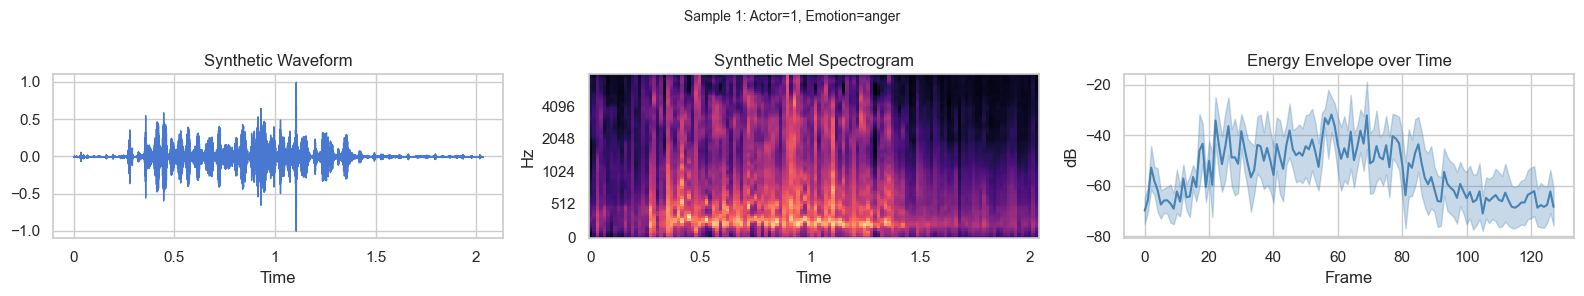


Sample 2: Actor=1, Emotion=disgust, Sentence=1
  Duration : 2.03s  |  RMS: 0.1113  |  Peak: 1.0000
  Mel range: [-80.0, 0.0] dB
  ✅ Looks good. Saved: sample_check_2_actor1_disgust.wav


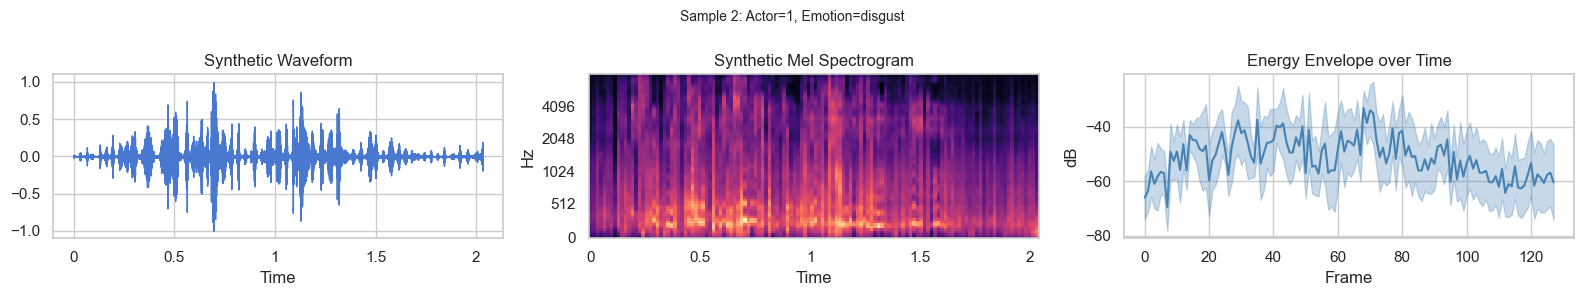


Sample 3: Actor=1, Emotion=fear, Sentence=1
  Duration : 2.03s  |  RMS: 0.1085  |  Peak: 1.0000
  Mel range: [-80.0, 0.0] dB
  ✅ Looks good. Saved: sample_check_3_actor1_fear.wav


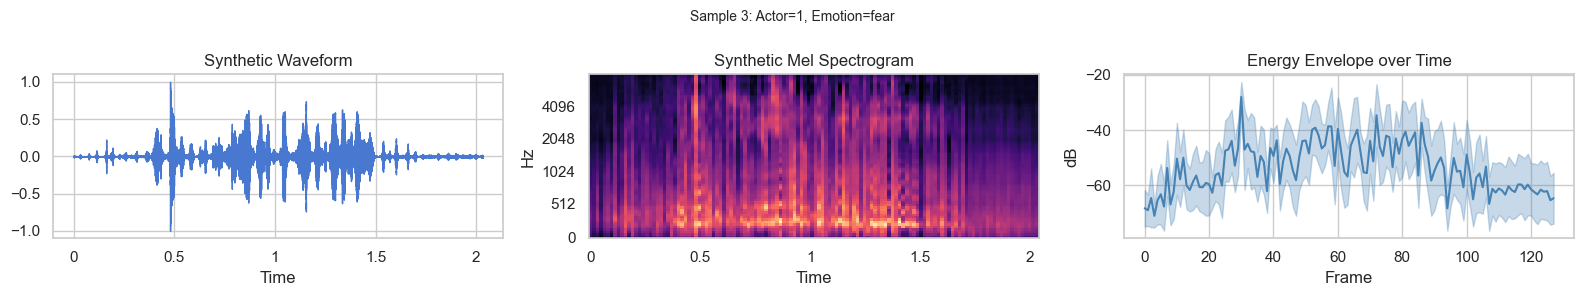


Sample 4: Actor=1, Emotion=happy, Sentence=1
  Duration : 2.03s  |  RMS: 0.0877  |  Peak: 1.0000
  Mel range: [-80.0, 0.0] dB
  ✅ Looks good. Saved: sample_check_4_actor1_happy.wav


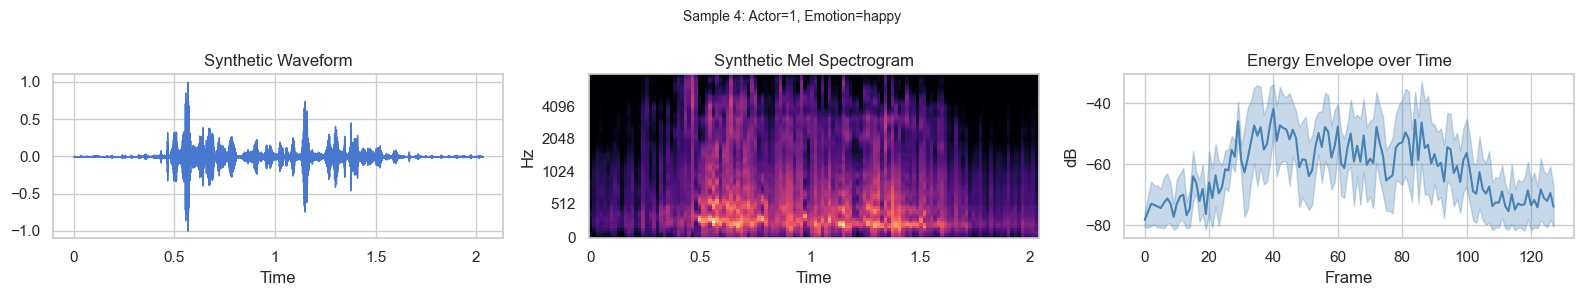


Sample 5: Actor=1, Emotion=neutral, Sentence=1
  Duration : 2.03s  |  RMS: 0.0985  |  Peak: 1.0000
  Mel range: [-80.0, 0.0] dB
  ✅ Looks good. Saved: sample_check_5_actor1_neutral.wav


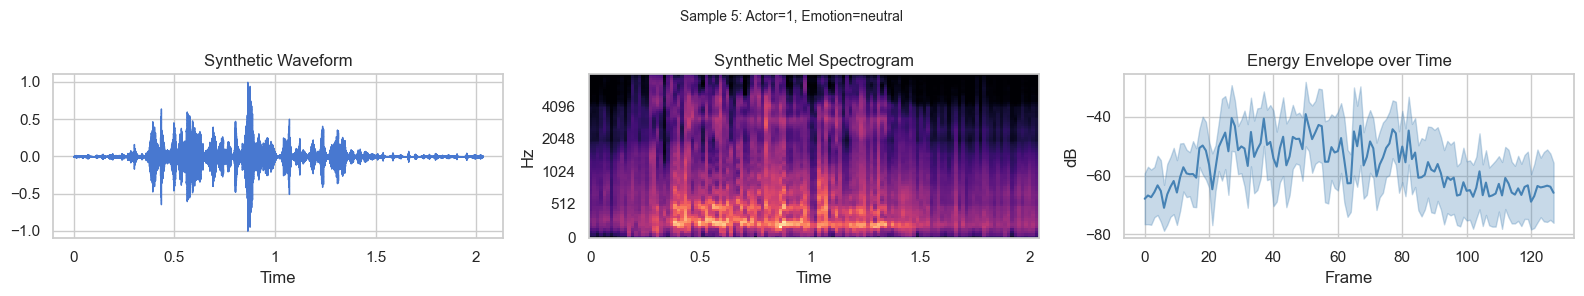


✅ EARLY CHECK PASSED — Proceed to full decode (Cell 9).


In [7]:
synth_emb_files = sorted(list(Path('./synthetic_embeddings').glob('synth_actor*_sent*_*.npy')))
print(f'Found {len(synth_emb_files)} synthetic embedding group files.')
test_groups = synth_emb_files[:5]

print('\n' + '='*55)
print('       EARLY AUDIO SAMPLE CHECK (5 samples)')
print('='*55)

sample_results = []
projector.eval()

for i, fpath in enumerate(test_groups):
    match = re.match(r'synth_actor(\d+)_sent(\d+)_(.+)\.npy', fpath.name)
    actor, sentence, emotion = int(match.group(1)), int(match.group(2)), match.group(3)

    synth_embs   = np.load(fpath)          # (35, 128, 768)
    emb_frames   = synth_embs[0]           # (128, 768) — first synthetic sample
    mel_2d       = frames_to_mel(emb_frames)  # (80, 128)
    wav          = mel_to_wav(mel_2d)         # waveform

    # Save
    sample_path = OUTPUTS_DIR / f'sample_check_{i+1}_actor{actor}_{emotion}.wav'
    sf.write(str(sample_path), wav, TARGET_SR)

    rms    = np.sqrt(np.mean(wav**2))
    peak   = np.abs(wav).max()
    silent = rms < 0.001
    flat   = wav.std() < 0.05  # True if waveform has almost no variation

    print(f'\nSample {i+1}: Actor={actor}, Emotion={emotion}, Sentence={sentence}')
    print(f'  Duration : {len(wav)/TARGET_SR:.2f}s  |  RMS: {rms:.4f}  |  Peak: {peak:.4f}')
    print(f'  Mel range: [{mel_2d.min():.1f}, {mel_2d.max():.1f}] dB')
    if silent:
        print('  ❌ Near-silent — check scaler or projector.')
    elif flat:
        print('  ⚠️  Waveform is flat — mel may lack temporal variation.')
    else:
        print(f'  ✅ Looks good. Saved: {sample_path.name}')

    sample_results.append({'silent': silent, 'flat': flat, 'rms': rms})

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 3))
    fig.suptitle(f'Sample {i+1}: Actor={actor}, Emotion={emotion}', fontsize=10)
    librosa.display.waveshow(wav, sr=TARGET_SR, ax=axes[0])
    axes[0].set_title('Synthetic Waveform')
    librosa.display.specshow(mel_2d, sr=TARGET_SR, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', fmax=FMAX,
                              ax=axes[1], cmap='magma')
    axes[1].set_title('Synthetic Mel Spectrogram')
    # Compare mel temporal std per frame
    axes[2].plot(mel_2d.mean(axis=0), color='steelblue', label='Mean energy')
    axes[2].fill_between(range(mel_2d.shape[1]),
                          mel_2d.mean(axis=0) - mel_2d.std(axis=0),
                          mel_2d.mean(axis=0) + mel_2d.std(axis=0),
                          alpha=0.3, color='steelblue')
    axes[2].set_title('Energy Envelope over Time')
    axes[2].set_xlabel('Frame'); axes[2].set_ylabel('dB')
    plt.tight_layout(); plt.show()
    ipd.display(ipd.Audio(wav, rate=TARGET_SR))

n_bad = sum(r['silent'] or r['flat'] for r in sample_results)
print('\n' + '='*55)
if n_bad == 0:
    print('✅ EARLY CHECK PASSED — Proceed to full decode (Cell 9).')
elif n_bad < 3:
    print(f'⚠️  {n_bad}/5 samples problematic. Check projector quality.')
else:
    print(f'❌ EARLY CHECK FAILED — {n_bad}/5 bad samples.')
    print('   Do NOT run Cell 9. Delete best_projector.pth and retrain.')
print('='*55)

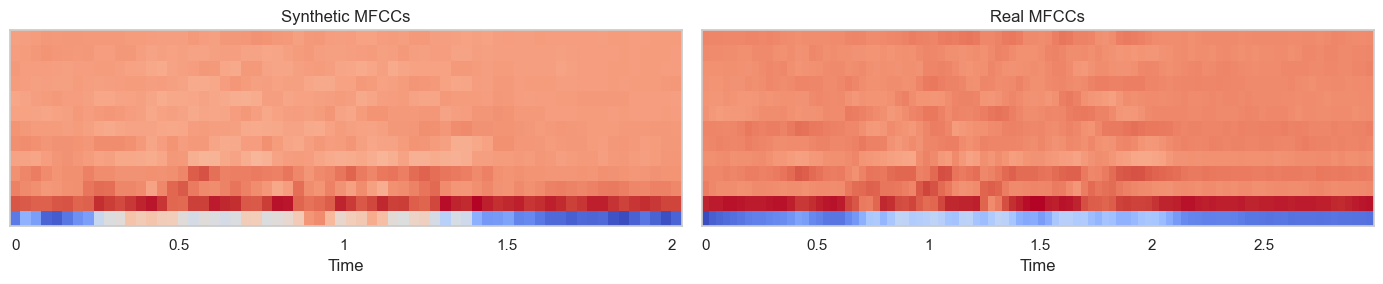

In [8]:
# Extract MFCC from a synthetic sample and compare to a real one
synth_wav, _ = sf.read('./outputs/sample_check_1_actor1_anger.wav')
real_wav, _  = librosa.load(file_index.iloc[0]['path'], sr=TARGET_SR)

synth_mfcc = librosa.feature.mfcc(y=synth_wav, sr=TARGET_SR, n_mfcc=13)
real_mfcc  = librosa.feature.mfcc(y=real_wav,  sr=TARGET_SR, n_mfcc=13)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
librosa.display.specshow(synth_mfcc, sr=TARGET_SR, x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title('Synthetic MFCCs')
librosa.display.specshow(real_mfcc,  sr=TARGET_SR, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title('Real MFCCs')
plt.tight_layout(); plt.show()

---
## CELL 9 — Full Synthetic Audio Generation

⚠️ **Only run after Cell 8 passes.**  
Skips files already generated to allow safe restart.

In [9]:
decode_log    = []
decode_errors = []
skipped       = 0
t_start       = time.time()
projector.eval()

print(f'Starting full audio generation...')
print(f'Total groups : {len(synth_emb_files)}')
print(f'Per group    : 35 synthetic samples')
print(f'Skipping     : groups already decoded\n')

for fpath in tqdm(synth_emb_files, desc='Decoding'):
    match = re.match(r'synth_actor(\d+)_sent(\d+)_(.+)\.npy', fpath.name)
    if not match: continue
    actor, sentence, emotion = int(match.group(1)), int(match.group(2)), match.group(3)

    out_dir = SYNTH_AUDIO_DIR / str(actor) / 'sessionSYNTH' / emotion
    out_dir.mkdir(parents=True, exist_ok=True)

    synth_embs   = np.load(fpath)   # (35, 128, 768)
    group_rms    = []

    for j, emb_frames in enumerate(synth_embs):
        fname    = out_dir / f'{actor}.SYNTH.{emotion}-{sentence:02d}-{j+1:03d}.wav'

        # Skip if already exists
        if fname.exists():
            skipped += 1
            continue

        try:
            mel_2d = frames_to_mel(emb_frames)  # (80, 128)
            wav    = mel_to_wav(mel_2d)
            sf.write(str(fname), wav, TARGET_SR)
            group_rms.append(np.sqrt(np.mean(wav**2)))
        except Exception as e:
            decode_errors.append({'actor': actor, 'sentence': sentence,
                                   'emotion': emotion, 'idx': j, 'error': str(e)})

    decode_log.append({'actor': actor, 'sentence': sentence, 'emotion': emotion,
                        'mean_rms': np.mean(group_rms) if group_rms else 0,
                        'n_decoded': len(group_rms)})

    if torch.cuda.is_available(): torch.cuda.empty_cache()

decode_df = pd.DataFrame(decode_log)
decode_df.to_csv('./outputs/decode_log.csv', index=False)
t_elapsed = time.time() - t_start

n_synth_wav = len(list(SYNTH_AUDIO_DIR.rglob('*.wav')))
print(f'\n✅ Decode complete!')
print(f'   WAV files generated : {decode_df["n_decoded"].sum()}')
print(f'   Skipped (existing)  : {skipped}')
print(f'   Total in directory  : {n_synth_wav}')
print(f'   Errors              : {len(decode_errors)}')
print(f'   Time elapsed        : {t_elapsed/60:.1f} min')
print(f'   Mean RMS            : {decode_df["mean_rms"].mean():.4f}')

Starting full audio generation...
Total groups : 640
Per group    : 35 synthetic samples
Skipping     : groups already decoded



Decoding: 100%|██████████| 640/640 [2:33:59<00:00, 14.44s/it]  



✅ Decode complete!
   WAV files generated : 22400
   Skipped (existing)  : 0
   Total in directory  : 22400
   Errors              : 0
   Time elapsed        : 154.0 min
   Mean RMS            : 0.1181


---
## CELL 10 — Mel Spectrogram Quality: Real vs Synthetic

Mel Spectrogram Similarity (Real vs Projected):
  Mean MSE        : 235.9252
  Mean Cosine Sim : 0.9707


C:\Users\Garv Sharma\AppData\Local\Temp\ipykernel_27012\2044936149.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim_df, x='emotion', y='cosine', order=emotion_order, palette='muted', ax=axes[0])
C:\Users\Garv Sharma\AppData\Local\Temp\ipykernel_27012\2044936149.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim_df, x='emotion', y='mse', order=emotion_order, palette='muted', ax=axes[1])


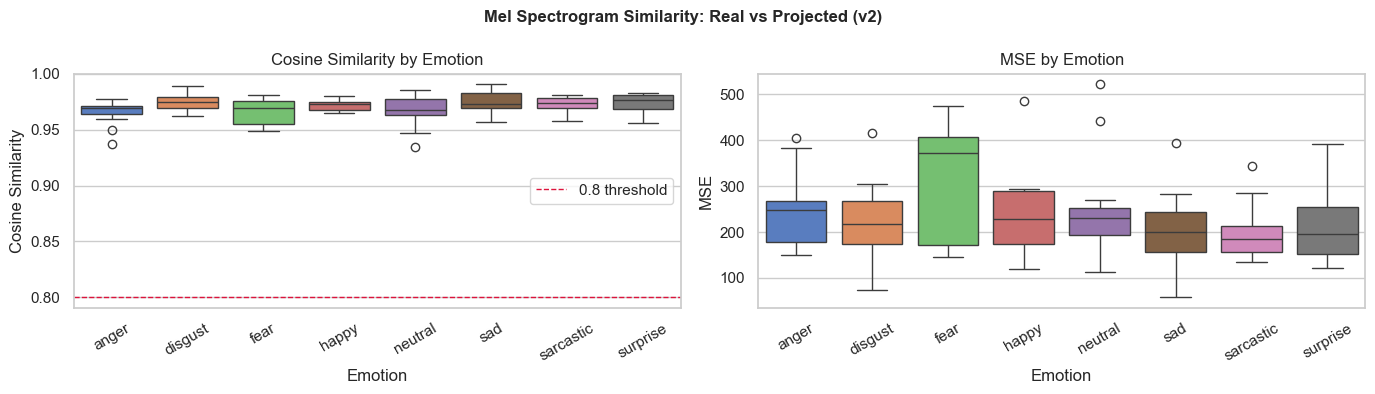

In [10]:
from scipy.spatial.distance import cosine as cosine_dist

sample_size = min(100, len(file_index))
sample_rows = file_index.sample(sample_size, random_state=42).reset_index(drop=True)

mse_scores, cosine_scores, emotion_tags = [], [], []
projector.eval()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    try:
        # Real mel
        real_mel = load_mel_frames(row['path'], TARGET_SR, N_MELS, N_FFT,
                                    HOP_LENGTH, WIN_LENGTH, FMIN, FMAX, TARGET_FRAMES)
        real_mel_2d = real_mel.T  # (80, 128)

        # Projected mel from real embedding
        emb_frames = real_emb_matrix[sample_rows.index[i]]  # (128, 768)
        pred_mel   = frames_to_mel(emb_frames)               # (80, 128)

        mse   = np.mean((real_mel_2d - pred_mel)**2)
        cos   = 1 - cosine_dist(real_mel_2d.flatten(), pred_mel.flatten())
        mse_scores.append(mse)
        cosine_scores.append(cos)
        emotion_tags.append(row['emotion'])
    except:
        pass

sim_df = pd.DataFrame({'emotion': emotion_tags, 'mse': mse_scores, 'cosine': cosine_scores})

print(f'Mel Spectrogram Similarity (Real vs Projected):')
print(f'  Mean MSE        : {np.mean(mse_scores):.4f}')
print(f'  Mean Cosine Sim : {np.mean(cosine_scores):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Mel Spectrogram Similarity: Real vs Projected (v2)', fontsize=12, fontweight='bold')
emotion_order = sorted(sim_df['emotion'].unique())
sns.boxplot(data=sim_df, x='emotion', y='cosine', order=emotion_order, palette='muted', ax=axes[0])
axes[0].set_title('Cosine Similarity by Emotion')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Cosine Similarity')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0.8, color='crimson', linestyle='--', linewidth=1, label='0.8 threshold')
axes[0].legend()
sns.boxplot(data=sim_df, x='emotion', y='mse', order=emotion_order, palette='muted', ax=axes[1])
axes[1].set_title('MSE by Emotion')
axes[1].set_xlabel('Emotion'); axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('./outputs/mel_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 11 — Emotion Classifier: Train on Real, Evaluate on Synthetic

In [11]:
le = LabelEncoder()
le.fit(EMOTIONS)

# Flatten real embeddings: (3200, 128, 768) → (3200, 98304)
real_X = real_emb_matrix.reshape(len(real_emb_matrix), -1)
real_y = le.transform(real_labels_df['emotion'].values)

synth_matrix    = np.load(SYNTH_EMB_DIR / 'all_synthetic_matrix.npy')  # (22400, 128, 768)
synth_labels_df = pd.read_csv(SYNTH_EMB_DIR / 'all_synthetic_labels.csv')
synth_X         = synth_matrix.reshape(len(synth_matrix), -1)           # (22400, 98304)
synth_y         = le.transform(synth_labels_df['emotion'].values)

print(f'Real  : X={real_X.shape}, y={real_y.shape}')
print(f'Synth : X={synth_X.shape}, y={synth_y.shape}')

# SVM on PCA-reduced features (full 98304-d is too large for SVM directly)
from sklearn.decomposition import PCA
print('\nReducing dimensionality with PCA (100 components)...')
pca = PCA(n_components=100, random_state=42)
real_X_pca  = pca.fit_transform(StandardScaler().fit_transform(real_X))
synth_X_pca = pca.transform(StandardScaler().fit_transform(synth_X))
print(f'  Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

print('\nTraining SVM on real data (cross-validation)...')
clf    = Pipeline([('svm', SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42))])
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(clf, real_X_pca, real_y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'  Cross-val Macro F1 (real): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

clf.fit(real_X_pca, real_y)
synth_pred = clf.predict(synth_X_pca)

acc       = accuracy_score(synth_y, synth_pred)
prec_mac  = precision_score(synth_y, synth_pred, average='macro',    zero_division=0)
rec_mac   = recall_score(synth_y, synth_pred,    average='macro',    zero_division=0)
f1_mac    = f1_score(synth_y, synth_pred,         average='macro',    zero_division=0)
f1_weight = f1_score(synth_y, synth_pred,         average='weighted', zero_division=0)

print(f'\n  ===== EVALUATION RESULTS =====')
print(f'  Accuracy        : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Macro Precision : {prec_mac:.4f}')
print(f'  Macro Recall    : {rec_mac:.4f}')
print(f'  Macro F1        : {f1_mac:.4f}')
print(f'  Weighted F1     : {f1_weight:.4f}')
print()

class_names = le.inverse_transform(sorted(np.unique(synth_y)))
print(classification_report(synth_y, synth_pred, target_names=class_names, zero_division=0))

if f1_mac >= 0.7:
    print('✅ Macro F1 ≥ 0.7 — Synthetic data is suitable for SER training.')
elif f1_mac >= 0.5:
    print('⚠️  Macro F1 0.5–0.7 — Moderate quality.')
else:
    print('❌ Macro F1 < 0.5 — Low quality. Check projector training.')

Real  : X=(3200, 98304), y=(3200,)
Synth : X=(22400, 98304), y=(22400,)

Reducing dimensionality with PCA (100 components)...
  Variance explained: 31.8%

Training SVM on real data (cross-validation)...
  Cross-val Macro F1 (real): 0.4651 ± 0.0152

  ===== EVALUATION RESULTS =====
  Accuracy        : 0.9830  (98.3%)
  Macro Precision : 0.9833
  Macro Recall    : 0.9830
  Macro F1        : 0.9829
  Weighted F1     : 0.9829

              precision    recall  f1-score   support

       anger       1.00      1.00      1.00      2800
     disgust       0.98      1.00      0.99      2800
        fear       0.96      1.00      0.98      2800
       happy       0.97      0.99      0.98      2800
     neutral       0.99      0.98      0.99      2800
         sad       0.99      0.95      0.97      2800
   sarcastic       0.99      0.95      0.97      2800
    surprise       0.99      1.00      0.99      2800

    accuracy                           0.98     22400
   macro avg       0.98      0.

---
## CELL 12 — Confusion Matrix

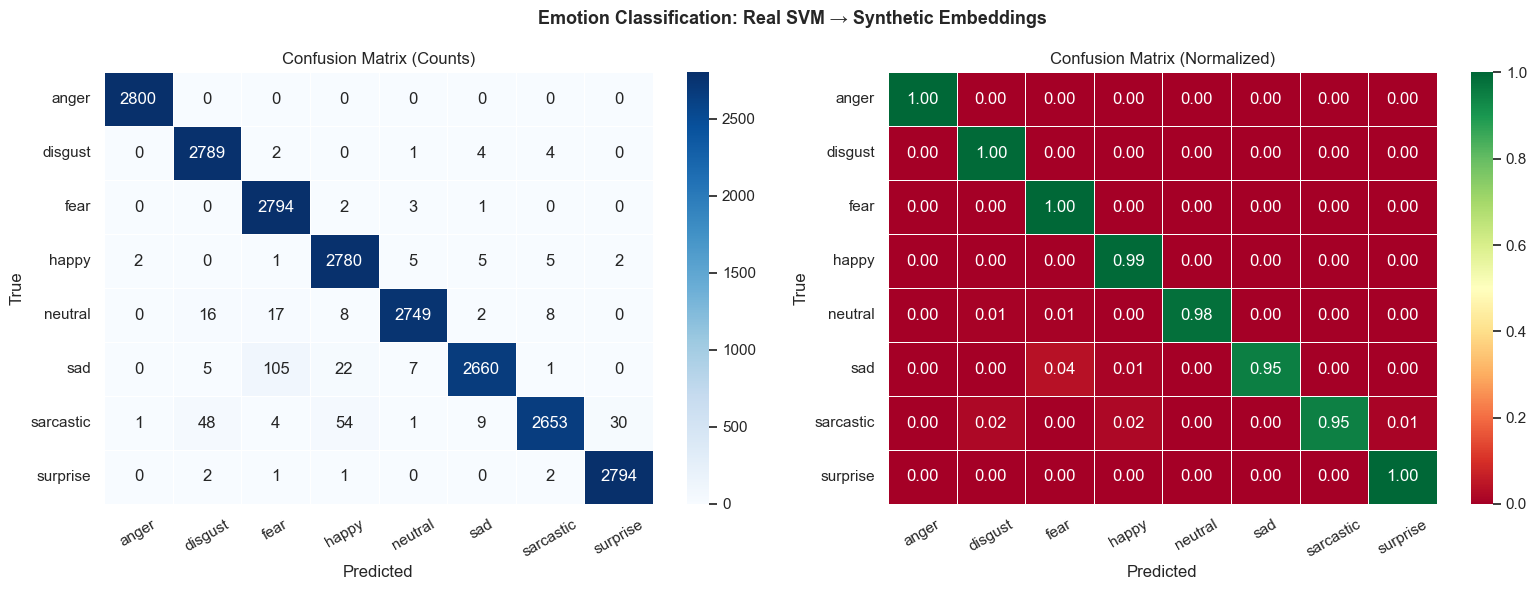

Saved to outputs/confusion_matrix.png


In [12]:
cm      = confusion_matrix(synth_y, synth_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Emotion Classification: Real SVM → Synthetic Embeddings',
             fontsize=13, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30); axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30); axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/confusion_matrix.png')

---
## CELL 13 — Per-Class Metrics Bar Chart

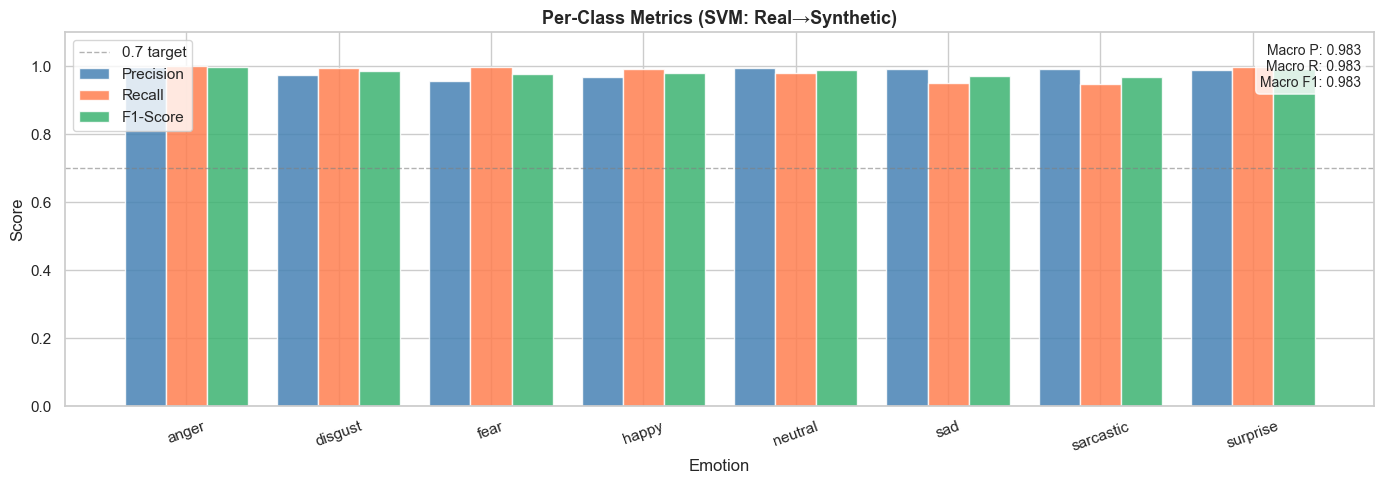

  Emotion  Precision  Recall     F1
    anger     0.9989  1.0000 0.9995
  disgust     0.9752  0.9961 0.9855
     fear     0.9555  0.9979 0.9762
    happy     0.9697  0.9929 0.9811
  neutral     0.9939  0.9818 0.9878
      sad     0.9922  0.9500 0.9706
sarcastic     0.9925  0.9475 0.9695
 surprise     0.9887  0.9979 0.9932


In [13]:
prec_per = precision_score(synth_y, synth_pred, average=None, zero_division=0)
rec_per  = recall_score(synth_y, synth_pred,    average=None, zero_division=0)
f1_per   = f1_score(synth_y, synth_pred,         average=None, zero_division=0)

metrics_df = pd.DataFrame({'Emotion': class_names,
                             'Precision': prec_per, 'Recall': rec_per, 'F1': f1_per})
metrics_df.to_csv('./outputs/per_class_metrics.csv', index=False)

x, width = np.arange(len(class_names)), 0.27
fig, ax   = plt.subplots(figsize=(14, 5))
ax.bar(x - width, prec_per, width, label='Precision',  color='steelblue',      alpha=0.85)
ax.bar(x,         rec_per,  width, label='Recall',     color='coral',           alpha=0.85)
ax.bar(x + width, f1_per,   width, label='F1-Score',   color='mediumseagreen',  alpha=0.85)
ax.set_title('Per-Class Metrics (SVM: Real→Synthetic)', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion'); ax.set_ylabel('Score')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=20)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='0.7 target')
ax.legend()
ax.text(0.99, 0.97, f'Macro P: {prec_mac:.3f}\nMacro R: {rec_mac:.3f}\nMacro F1: {f1_mac:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('./outputs/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

---
## CELL 14 — Final Pipeline Summary Report

In [14]:
n_synth_wav = len(list(SYNTH_AUDIO_DIR.rglob('*.wav')))
n_real      = len(file_index)

print('=' * 65)
print('          FINAL PIPELINE SUMMARY REPORT (v2)')
print('=' * 65)
print(f'  Real audio files          : {n_real}')
print(f'  Synthetic WAV files       : {n_synth_wav}')
print(f'  Dataset inflation         : {(n_synth_wav / n_real):.1f}×')
print()
print('  --- v2 Architecture ---')
print(f'  Embedding shape           : ({TARGET_FRAMES}, {HUBERT_DIM}) per file')
print(f'  Projector                 : {HUBERT_DIM}→80 per frame (FrameProjector)')
print(f'  Training pairs            : {n_real * TARGET_FRAMES:,} frames')
print(f'  Vocoder                   : Griffin-Lim (64 iterations)')
print()
print('  --- Mel Quality ---')
print(f'  Mean Cosine Similarity    : {np.mean(cosine_scores):.4f}')
print(f'  Mean MSE                  : {np.mean(mse_scores):.4f}')
print()
print('  --- Emotion Classification ---')
print(f'  Accuracy                  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Macro Precision           : {prec_mac:.4f}')
print(f'  Macro Recall              : {rec_mac:.4f}')
print(f'  Macro F1                  : {f1_mac:.4f}')
print(f'  Weighted F1               : {f1_weight:.4f}')
print()
print('  --- Output Locations ---')
print(f'  Synthetic audio           : ./synthetic_audio/')
print(f'  Projector weights         : ./outputs/best_projector.pth')
print(f'  Scalers                   : ./outputs/emb_scaler.pkl, mel_scaler.pkl')
print(f'  Evaluation plots          : ./outputs/*.png')
print(f'  Metrics CSV               : ./outputs/per_class_metrics.csv')
print()

if f1_mac >= 0.7 and acc >= 0.65:
    verdict = '✅ HIGH QUALITY — Synthetic data suitable for SER training.'
elif f1_mac >= 0.5:
    verdict = '⚠️  MODERATE — Usable. Consider more projector epochs.'
else:
    verdict = '❌ LOW QUALITY — Revisit projector or embedding quality.'

print(f'  OVERALL VERDICT: {verdict}')
print('=' * 65)

          FINAL PIPELINE SUMMARY REPORT (v2)
  Real audio files          : 3200
  Synthetic WAV files       : 22400
  Dataset inflation         : 7.0×

  --- v2 Architecture ---
  Embedding shape           : (128, 768) per file
  Projector                 : 768→80 per frame (FrameProjector)
  Training pairs            : 409,600 frames
  Vocoder                   : Griffin-Lim (64 iterations)

  --- Mel Quality ---
  Mean Cosine Similarity    : 0.9707
  Mean MSE                  : 235.9252

  --- Emotion Classification ---
  Accuracy                  : 0.9830  (98.3%)
  Macro Precision           : 0.9833
  Macro Recall              : 0.9830
  Macro F1                  : 0.9829
  Weighted F1               : 0.9829

  --- Output Locations ---
  Synthetic audio           : ./synthetic_audio/
  Projector weights         : ./outputs/best_projector.pth
  Scalers                   : ./outputs/emb_scaler.pkl, mel_scaler.pkl
  Evaluation plots          : ./outputs/*.png
  Metrics CSV            